### Imports

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from torchinfo import summary

from utility_functions.seed_utility import set_seed
from utility_functions.data_utility import HoloPhaseDataset
from models.phase_reconstructor import UNetPhaseReconstruction_V2
from engines.reconstructor_engine import model_fit

### Manual Seeding for Reproducibility

In [2]:
set_seed(seed=42, deterministic=True)

### Loading Dataset

In [3]:
ROOT_DIR = "datasets/reconstruction_dataset"

train_dataset = HoloPhaseDataset(root_dir=ROOT_DIR, split="train")
val_dataset = HoloPhaseDataset(root_dir=ROOT_DIR, split="val")

### HyperParameters

In [4]:
TRAIN_BATCH_SIZE = 4
VAL_BATCH_SIZE = 1
DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
NUM_WORKERS = os.cpu_count()

LEARNING_RATE = 1e-3

### DataLoader Definitions

In [5]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, 
                              prefetch_factor=4, persistent_workers=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, 
                            prefetch_factor=4, persistent_workers=True, num_workers=NUM_WORKERS)


### Model Architecture

In [6]:
unet_model = UNetPhaseReconstruction_V2(in_channels=1, out_channels=1)
summary(model=unet_model, input_size=(4, 1, 256, 256), 
        col_names=["input_size", "output_size", "num_params", "params_percent", "trainable"], col_width=20)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Param %              Trainable
UNetPhaseReconstruction_V2               [4, 1, 256, 256]     [4, 1, 256, 256]     --                        --              True
├─EncoderBlock: 1-1                      [4, 1, 256, 256]     [4, 32, 256, 256]    --                        --              True
│    └─Sequential: 2-1                   [4, 1, 256, 256]     [4, 32, 256, 256]    --                        --              True
│    │    └─Conv2d: 3-1                  [4, 1, 256, 256]     [4, 32, 256, 256]    320                    0.00%              True
│    │    └─ReLU: 3-2                    [4, 32, 256, 256]    [4, 32, 256, 256]    --                        --              --
│    └─MaxPool2d: 2-2                    [4, 32, 256, 256]    [4, 32, 128, 128]    --                        --              --
├─EncoderBlock: 1-2                      [4, 32, 128, 128]    [4, 64, 128, 128]    --    

In [7]:
unet_model = unet_model.to(DEVICE)

### Loss & Optimizer

In [8]:
loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params=unet_model.parameters(), lr=LEARNING_RATE)

### Training

In [9]:
history = model_fit(model=unet_model, train_loader=train_dataloader, val_loader=val_dataloader,
                    loss_function=loss, optimizer=optimizer, device=DEVICE, total_epochs=100, 
                    latest_checkpoint_path="./checkpoint/reconstruction/latest_checkpoint_v2_MSELoss.pth",
                    save_dir="./checkpoint/reconstruction")

[INFO] NO CHECKPOINT FOUND. STARTING TRAINING FROM SCRATCH ..........


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Step:   0%|          | 0/99 [00:00<?, ?it/s]

Validation Step:   0%|          | 0/49 [00:00<?, ?it/s]

||      Epoch 1/100 Summary      ||
train_loss:0.570630, train_ssim:0.736469, train_psnr:18.611845
valid_loss:0.190978, valid_ssim:0.870576, valid_psnr:22.638605
[INFO] VALIDATION SSIM IMPROVED FROM 0.000000 TO 0.870576.
[INFO] BEST CHECKPOINT SAVED AT ./checkpoint/reconstruction/best_checkpoint_v2_MSELoss.pth


...

Validation Step:   0%|          | 0/49 [00:00<?, ?it/s]

||      Epoch 99/100 Summary      ||
train_loss:0.007114, train_ssim:0.984347, train_psnr:37.654305
valid_loss:0.101599, valid_ssim:0.942664, valid_psnr:25.379547


Training Step:   0%|          | 0/99 [00:00<?, ?it/s]

Validation Step:   0%|          | 0/49 [00:00<?, ?it/s]

||      Epoch 100/100 Summary      ||
train_loss:0.006021, train_ssim:0.985565, train_psnr:38.378777
valid_loss:0.096750, valid_ssim:0.946600, valid_psnr:25.591944


### Plot Training History

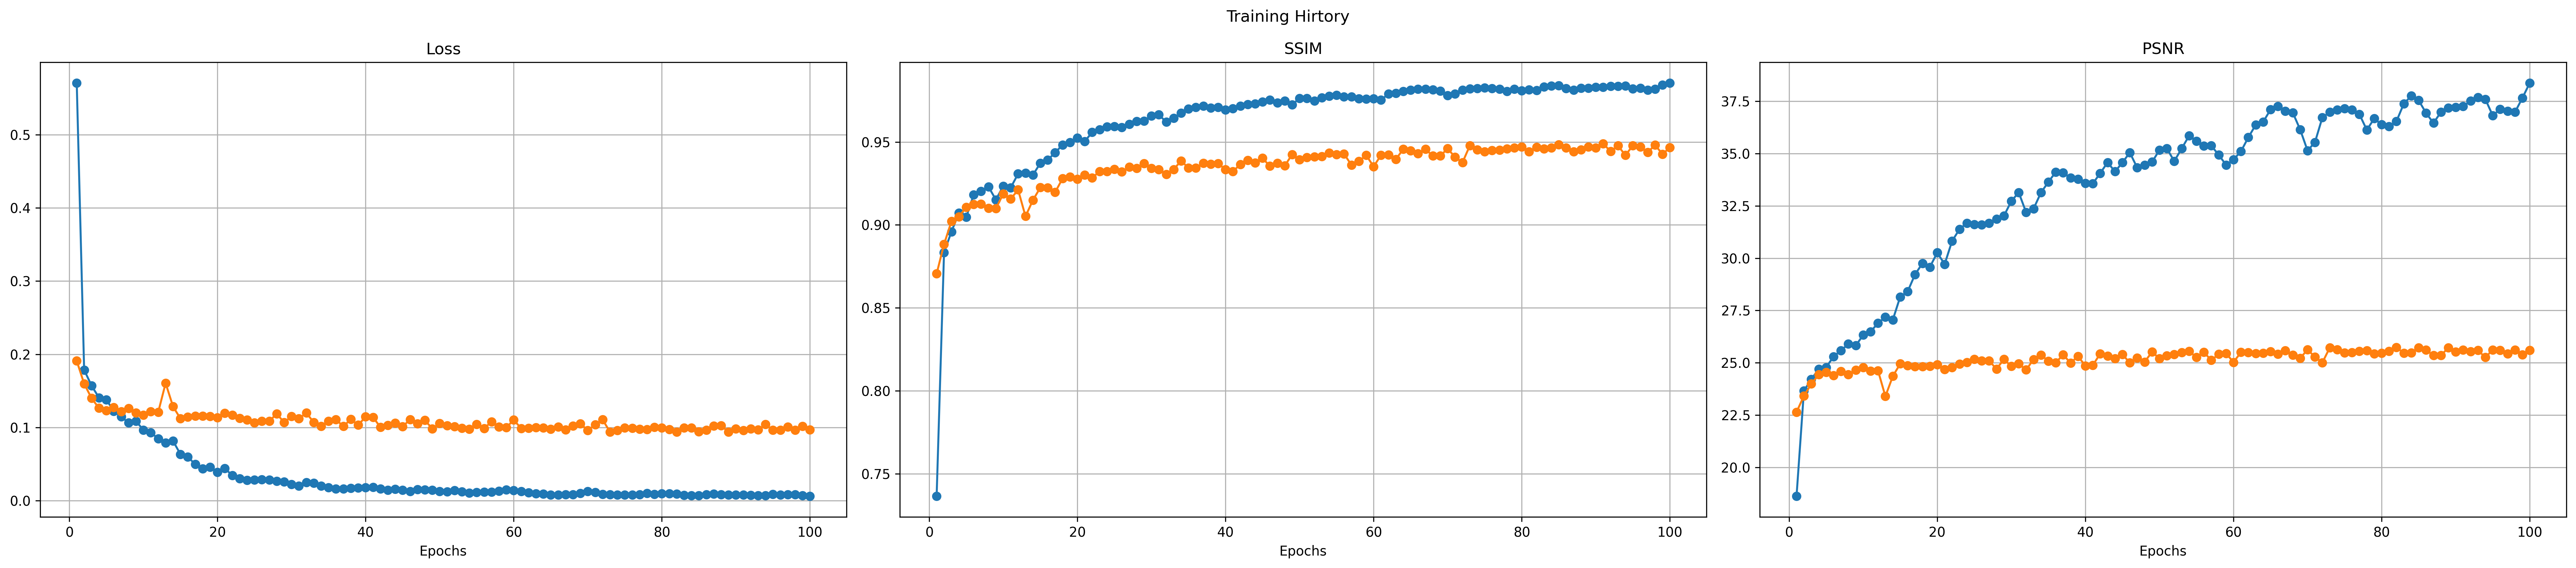

In [10]:
import torch
import matplotlib.pyplot as plt

checkpoint_path = "./checkpoint/reconstruction/latest_checkpoint_v2_MSELoss.pth"
checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))

history = checkpoint["history"]
epochs = range(1, len(history["train_loss"])+1)
train_loss = history["train_loss"]; val_loss = history["val_loss"]
train_ssim = history["train_ssim"]; val_ssim = history["val_ssim"]
train_psnr = history["train_psnr"]; val_psnr = history["val_psnr"]

plt.figure(figsize=(27, 6), dpi=300)
plt.suptitle("Training Hirtory")

plt.subplot(131)
plt.plot(epochs, train_loss, "o-", label="Training")
plt.plot(epochs, val_loss, "o-", label="Validation")
plt.grid();plt.xlabel("Epochs"); plt.title("Loss")

plt.subplot(132)
plt.plot(epochs, train_ssim, "o-", label="Training")
plt.plot(epochs, val_ssim, "o-", label="Validation")
plt.grid();plt.xlabel("Epochs"); plt.title("SSIM")

plt.subplot(133)
plt.plot(epochs, train_psnr, "o-", label="Training")
plt.plot(epochs, val_psnr, "o-", label="Validation")
plt.grid();plt.xlabel("Epochs"); plt.title("PSNR")

plt.tight_layout()
plt.savefig("./checkpoint/reconstruction/training_history_v2_MSELoss.png")
plt.show()


### Results on Test set

In [11]:
import os
import torch
from torch.utils.data import DataLoader
from utility_functions.data_utility import HoloPhaseDataset
from models.phase_reconstructor import UNetPhaseReconstruction_V2
from utility_functions.inference_utility import get_result_for_dataset
from utility_functions.seed_utility import set_seed

In [12]:
set_seed(seed=42)

In [13]:
ROOT_DIR = "./datasets/reconstruction_dataset"
DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
NUM_WORKERS = os.cpu_count()
CHECKPOINT_PATH = "./checkpoint/reconstruction/best_checkpoint_v2_MSELoss.pth"

# Loading test dataset
test_dataset = HoloPhaseDataset(root_dir=ROOT_DIR, split="test")
test_loader = DataLoader(dataset=test_dataset, batch_size=1, shuffle=False, 
                            prefetch_factor=4, persistent_workers=True, num_workers=NUM_WORKERS)

# Loading saved model
unet_model = UNetPhaseReconstruction_V2(in_channels=1, out_channels=1)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device("cpu"))
unet_model.load_state_dict(checkpoint["model_state_dict"])
unet_model = unet_model.to(DEVICE)

get_result_for_dataset(model=unet_model, loader=test_loader, device=DEVICE)


Predicting:   0%|          | 0/49 [00:00<?, ?it/s]

[INFO] FOR THE DATASET AVERAGE SSIM: 95.1925%, AVERAGE PSNR: 25.0024dB


### Inference Script

In [14]:
from torchvision import io
import numpy as np
import torch
import matplotlib.pyplot as plt

from utility_functions.inference_utility import predict
from models.phase_reconstructor import UNetPhaseReconstruction_V2


In [15]:
holo_path = "./datasets/reconstruction_dataset/test/holo/defocused_1a_2_1813_276.png"
phase_path = "./datasets/reconstruction_dataset/test/phase/defocused_1a_2_1813_276.raw"
checkpoint_path = "./checkpoint/reconstruction/best_checkpoint_v2_MSELoss.pth"

DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
unet_model = UNetPhaseReconstruction_V2(in_channels=1, out_channels=1).to(DEVICE)
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
unet_model.load_state_dict(checkpoint["model_state_dict"])

X = io.read_image(path=holo_path, mode=io.ImageReadMode.GRAY).unsqueeze(dim=0).div(255.0).to(torch.float32) # (1, 1, 256, 256)
phase = np.fromfile(file=phase_path, dtype=np.float32).reshape((256, 256)) # (256, 256)
Y = torch.from_numpy(np.expand_dims(phase, axis=0)).unsqueeze(dim=0)

Y_pred, ssim, psnr = predict(X, unet_model, DEVICE, Y)

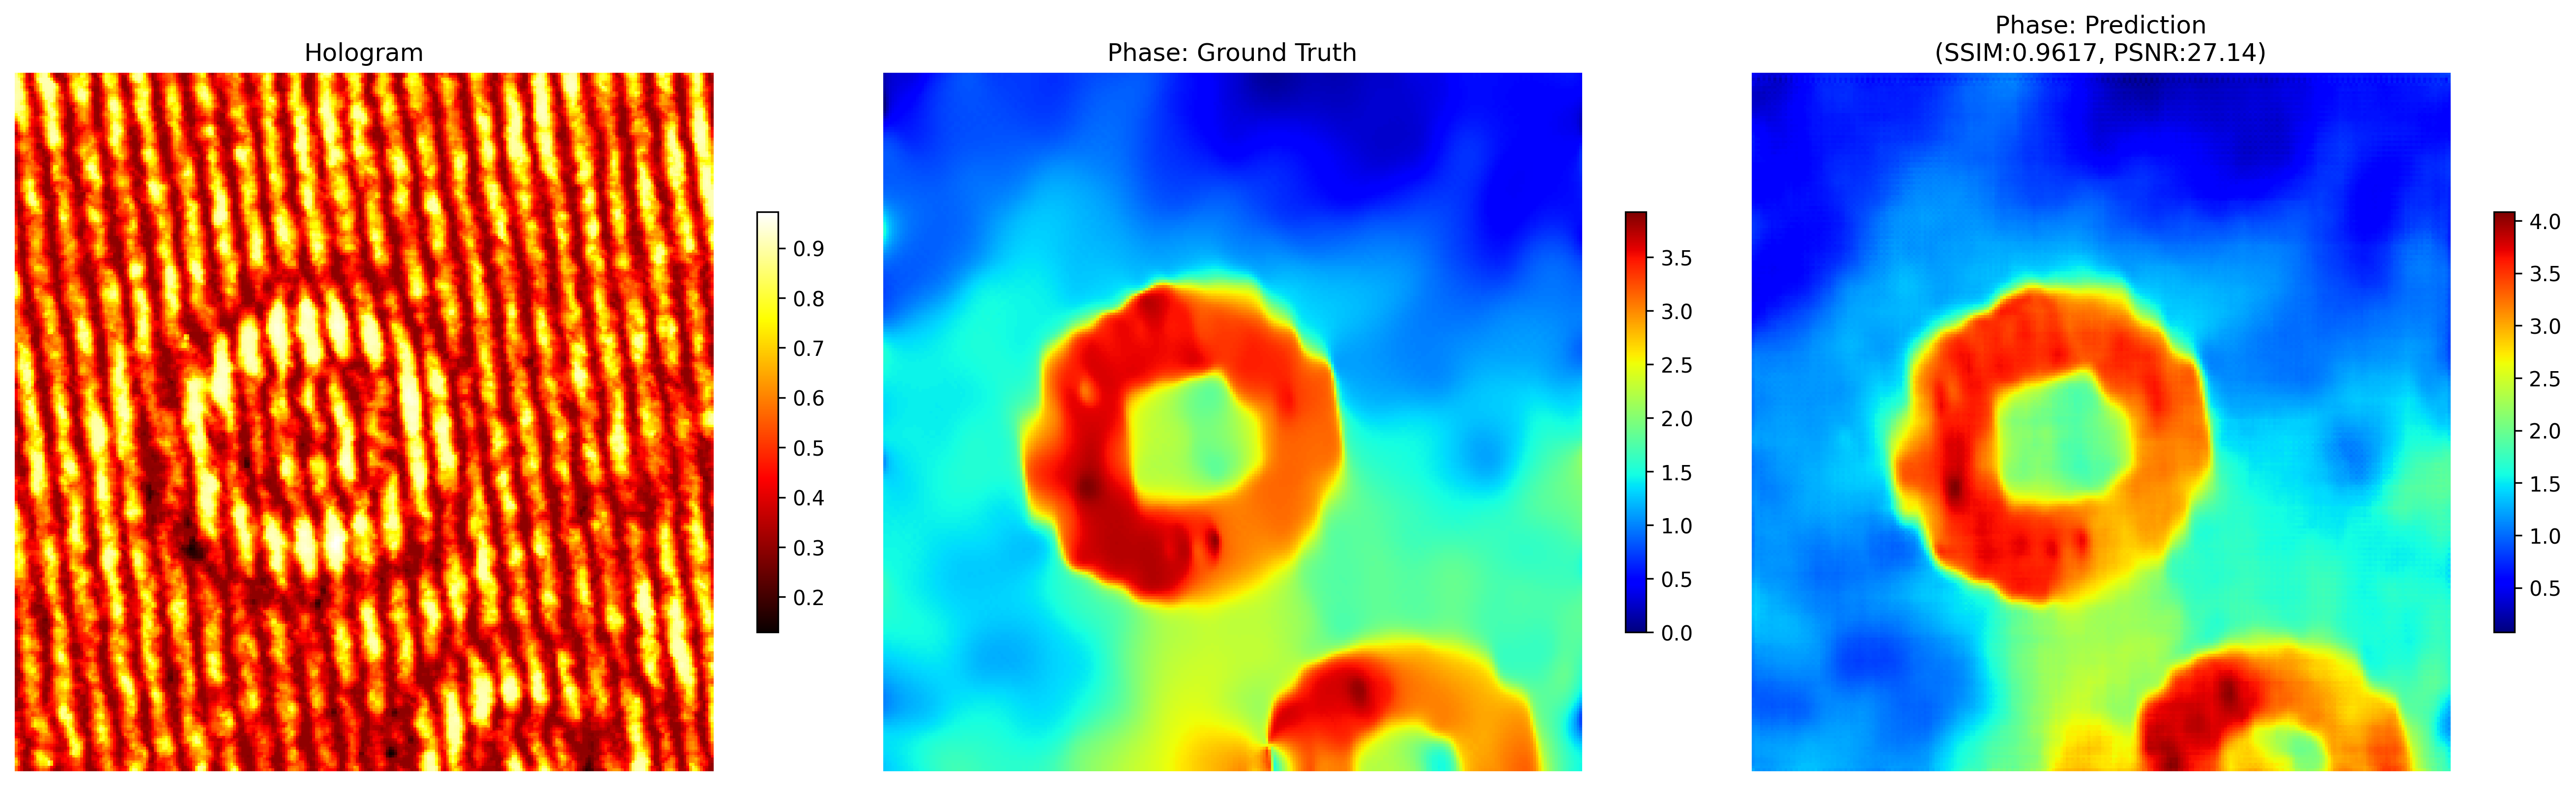

In [16]:
plt.figure(figsize=(18, 6), dpi=300)

plt.subplot(131)
plt.imshow(X.squeeze(), cmap="hot")
plt.axis("off"); plt.colorbar(shrink=0.5)
plt.title("Hologram")

plt.subplot(132)
plt.imshow(Y.squeeze(), cmap="jet")
plt.axis("off"); plt.colorbar(shrink=0.5)
plt.title("Phase: Ground Truth")

plt.subplot(133)
plt.imshow(Y_pred.squeeze(), cmap="jet")
plt.axis("off"); plt.colorbar(shrink=0.5)
plt.title(f"Phase: Prediction\n(SSIM:{ssim:0.4f}, PSNR:{psnr:0.2f})")

plt.tight_layout()
plt.savefig("./checkpoint/reconstruction/inference.png")
plt.show()

### Few Predictions on Test Dataset

In [17]:
import os
import math
import torch
from torch.utils.data import DataLoader
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utility_functions.data_utility import HoloPhaseDataset
from models.phase_reconstructor import UNetPhaseReconstruction_V2
from engines.reconstructor_engine import compute_data_range

ROOT_DIR = "./datasets/reconstruction_dataset"
DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
NUM_WORKERS = os.cpu_count()
CHECKPOINT_PATH = "./checkpoint/reconstruction/best_checkpoint_v2_MSELoss.pth"

# Loading test dataset
test_dataset = HoloPhaseDataset(root_dir=ROOT_DIR, split="test")
test_loader = DataLoader(dataset=test_dataset, batch_size=1, shuffle=False, 
                            prefetch_factor=4, persistent_workers=True, num_workers=NUM_WORKERS)
test_data_range = compute_data_range(test_loader, device=DEVICE)

# Loading saved model
unet_model = UNetPhaseReconstruction_V2(in_channels=1, out_channels=1)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device("cpu"))
unet_model.load_state_dict(checkpoint["model_state_dict"])
unet_model = unet_model.to(DEVICE)

ssim_metric = StructuralSimilarityIndexMeasure(data_range=test_data_range).to(DEVICE)
psnr_metric = PeakSignalNoiseRatio(data_range=test_data_range).to(DEVICE)

ssim_list, psnr_list = [], []
X_list, Y_list, Y_pred_list = [], [], []
for X, Y in tqdm(test_loader, total=len(test_loader)):
    X, Y = X.to(DEVICE), Y.to(DEVICE)
    with torch.no_grad():
        Y_pred = unet_model(X)
        ssim = ssim_metric(Y_pred, Y).item()
        psnr = psnr_metric(Y_pred, Y).item()
    X_list.append(X); Y_list.append(Y); Y_pred_list.append(Y_pred)
    ssim_list.append(ssim)
    psnr_list.append(psnr)
    ssim_metric.reset()
    psnr_metric.reset()

X_list = torch.cat(X_list, dim=0); Y_list = torch.cat(Y_list, dim=0); Y_pred_list = torch.cat(Y_pred_list, dim=0)

  0%|          | 0/49 [00:00<?, ?it/s]

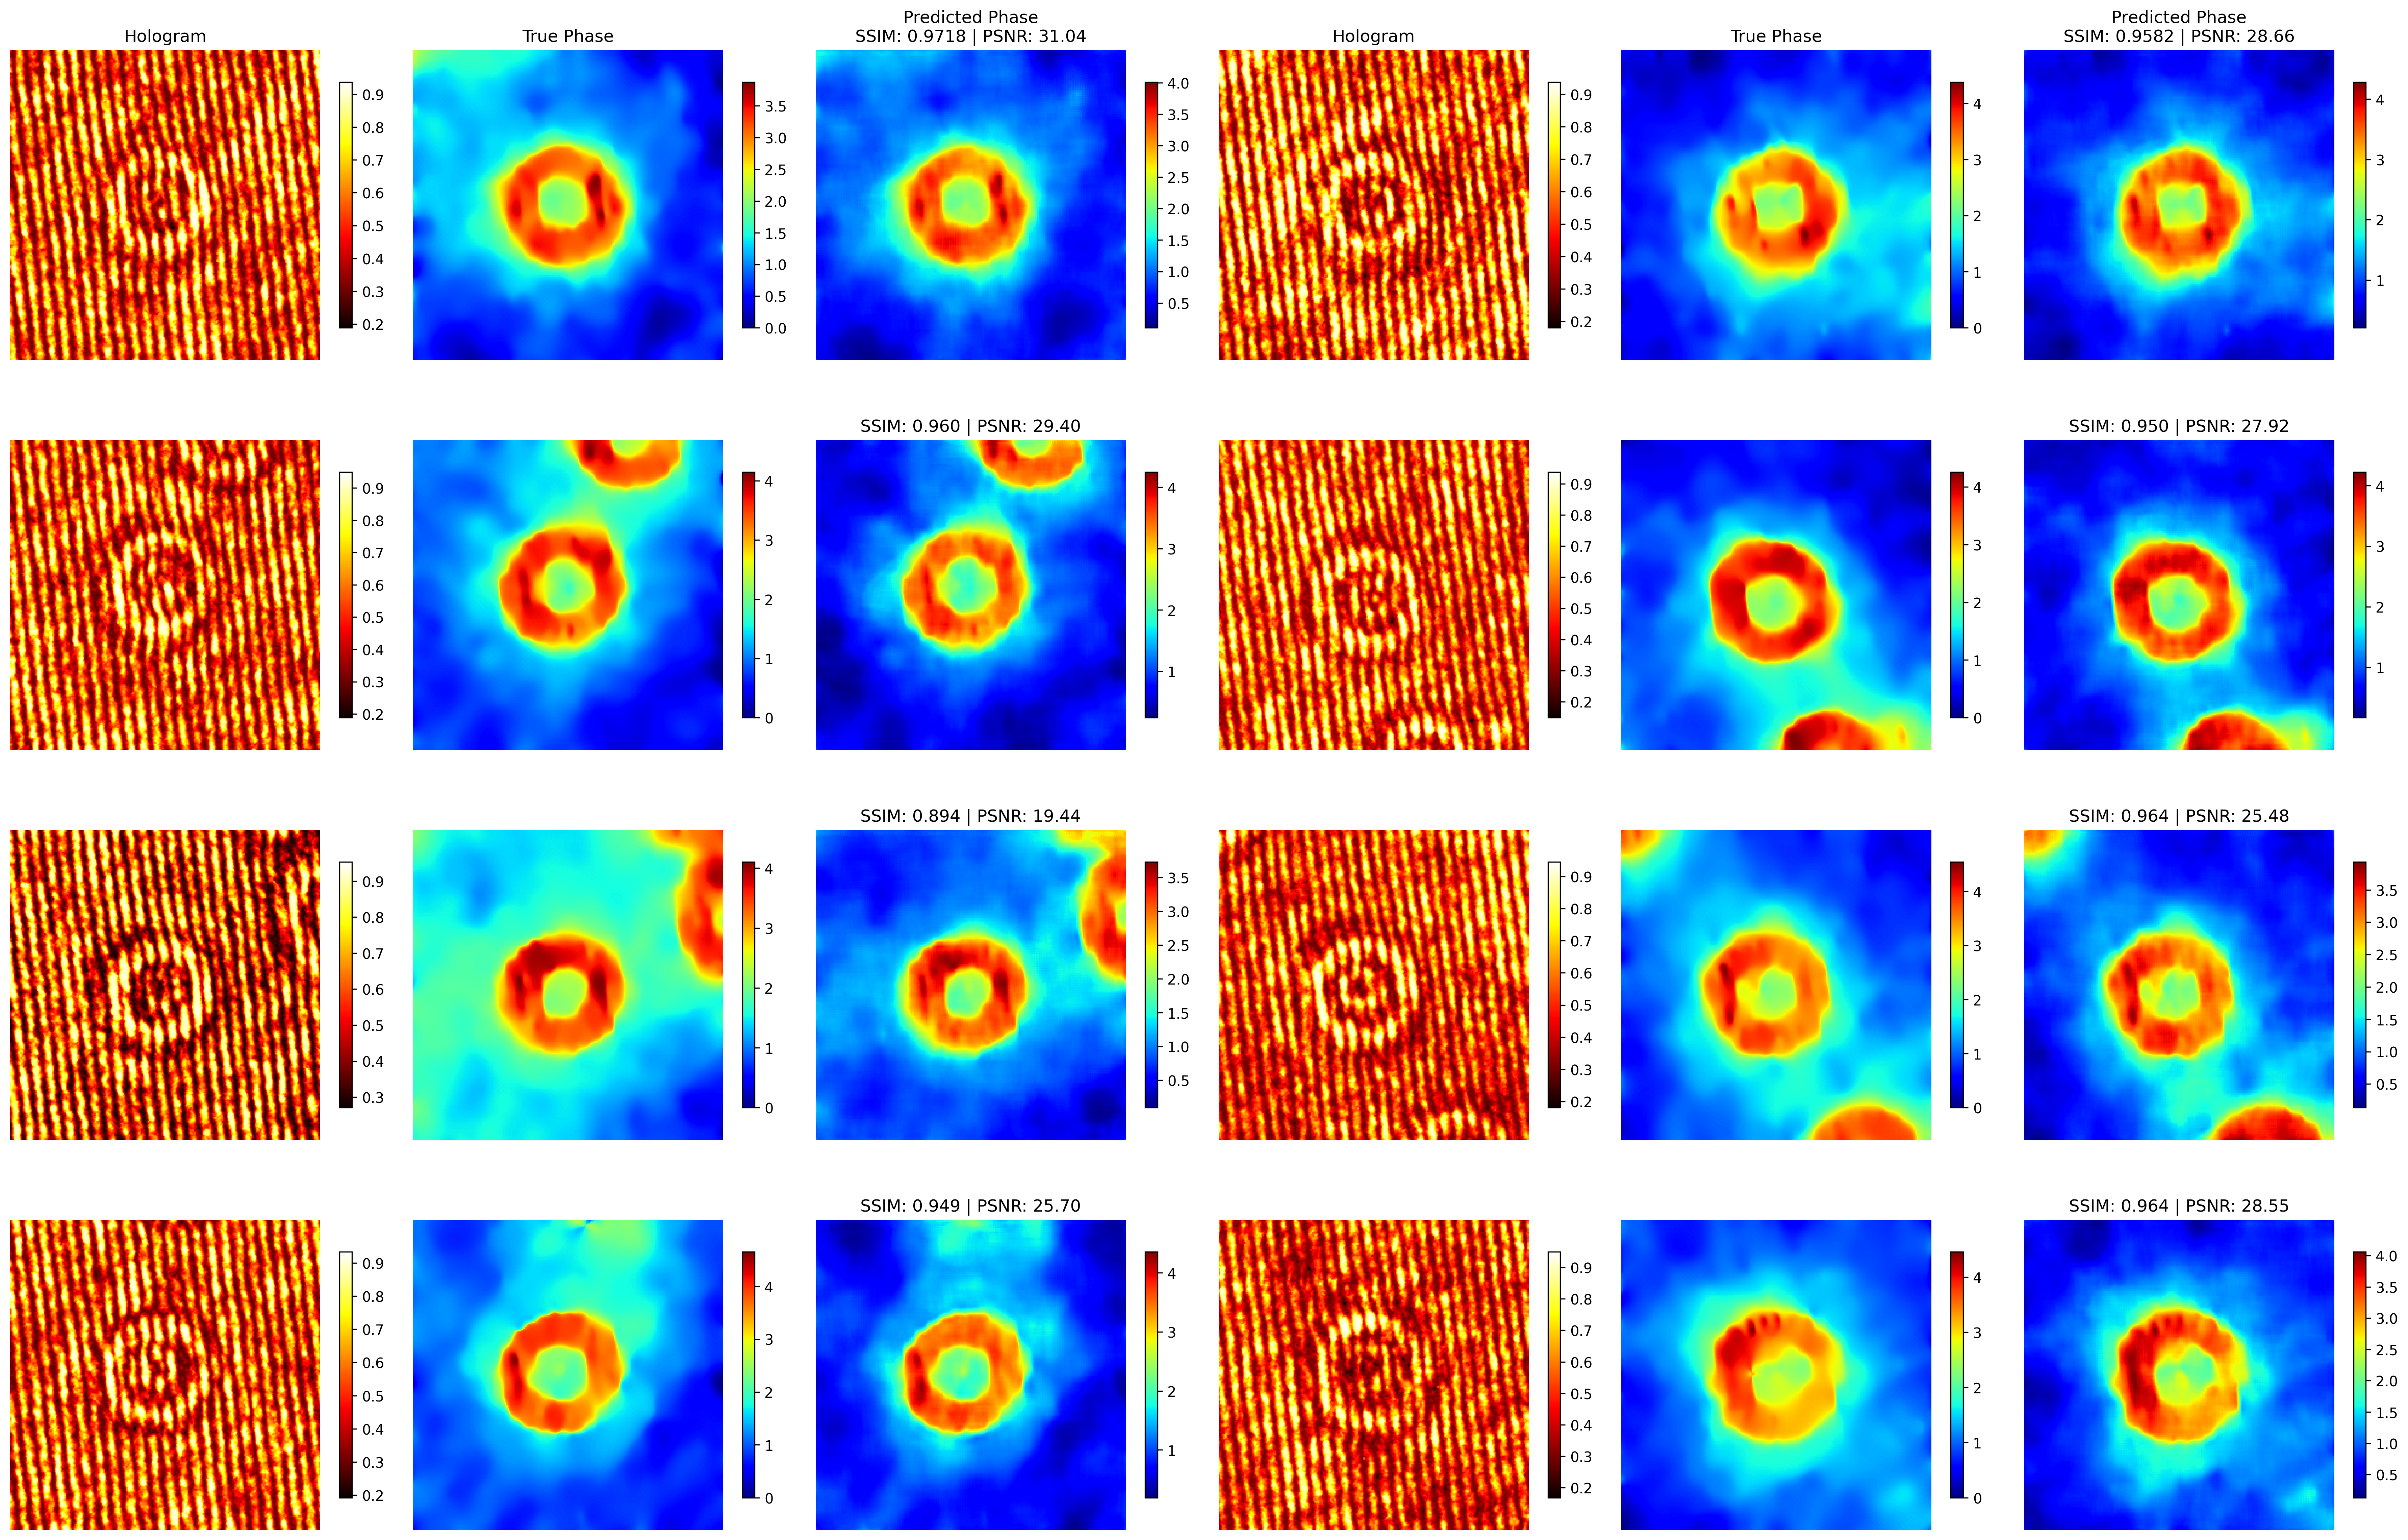

In [18]:
def plot_predictions(X_list, Y_list, Y_pred_list, ssim_list, psnr_list, num_samples=16, samples_per_row=2, subplot_width=4):
    total_plots = num_samples*3
    cols = samples_per_row*3
    rows = math.ceil(total_plots/cols)

    plt.figure(figsize=(subplot_width*cols, subplot_width*rows), dpi=300)

    for i in range(num_samples):
        row = i // samples_per_row
        col_group = i % samples_per_row

        base_col = col_group * 3

        # --- Hologram (Input) ---
        plt.subplot(rows, cols, row * cols + base_col + 1)
        plt.imshow(X_list[i].permute(1, 2, 0).cpu(), cmap="hot")
        plt.axis("off")
        plt.colorbar(shrink=0.6)
        if row == 0: plt.title("Hologram")

        # --- Ground Truth ---
        plt.subplot(rows, cols, row * cols + base_col + 2)
        plt.imshow(Y_list[i].permute(1, 2, 0).cpu(), cmap="jet")
        plt.axis("off")
        plt.colorbar(shrink=0.6)
        if row == 0: plt.title("True Phase")


        # --- Prediction ---
        plt.subplot(rows, cols, row * cols + base_col + 3)
        plt.imshow(Y_pred_list[i].permute(1, 2, 0).cpu(), cmap="jet")
        plt.title(f"SSIM: {ssim_list[i]:.3f} | PSNR: {psnr_list[i]:.2f}")
        plt.axis("off")
        plt.colorbar(shrink=0.6)
        if row == 0: plt.title(f"Predicted Phase\nSSIM: {ssim_list[i]:.4f} | PSNR: {psnr_list[i]:.2f}")


    plt.tight_layout()
    plt.savefig("./checkpoint/reconstruction/prediction_v2_MSELoss.png")
    plt.show()


plot_predictions(X_list, Y_list, Y_pred_list, ssim_list, psnr_list, num_samples=8)